In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('backpack.csv')

In [40]:
df.head(7)

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312
5,5,Nike,Canvas,Medium,10.0,No,Yes,NaN,Black,7.241812,20.01553
6,6,Nike,NaN,Large,3.0,No,No,Backpack,Green,6.828123,84.80500


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    300000 non-null  int64  
 1   Brand                 290295 non-null  object 
 2   Material              291653 non-null  object 
 3   Size                  293405 non-null  object 
 4   Compartments          300000 non-null  float64
 5   Laptop Compartment    292556 non-null  object 
 6   Waterproof            292950 non-null  object 
 7   Style                 292030 non-null  object 
 8   Color                 290050 non-null  object 
 9   Weight Capacity (kg)  299862 non-null  float64
 10  Price                 300000 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 25.2+ MB


In [42]:
(df.isna().sum()/len(df)) * 100

id                      0.000000
Brand                   3.235000
Material                2.782333
Size                    2.198333
Compartments            0.000000
Laptop Compartment      2.481333
Waterproof              2.350000
Style                   2.656667
Color                   3.316667
Weight Capacity (kg)    0.046000
Price                   0.000000
dtype: float64

In [43]:

 
if 'id' in df.columns:
    df = df.drop(columns=['id'])

for col in ['Price', 'Weight Capacity (kg)', 'Compartments']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

# бин. пр. в 0, 1 
df['Laptop Compartment'] = df['Laptop Compartment'].map({'Yes': 1, 'No': 0, 'Unknown': 0}).fillna(0).astype(int)
df['Waterproof'] = df['Waterproof'].map({'Yes': 1, 'No': 0, 'Unknown': 0}).fillna(0).astype(int)

# порядковые
size_map = {'Small': 1, 'Medium': 2, 'Large': 3, 'Unknown': 0}
if 'Size' in df.columns:
    df['Size'] = df['Size'].map(size_map).fillna(0).astype(int)

# onehot
remaining_cats = ['Brand', 'Material', 'Style', 'Color']


df_encoded = pd.get_dummies(df, columns=remaining_cats, drop_first=True)



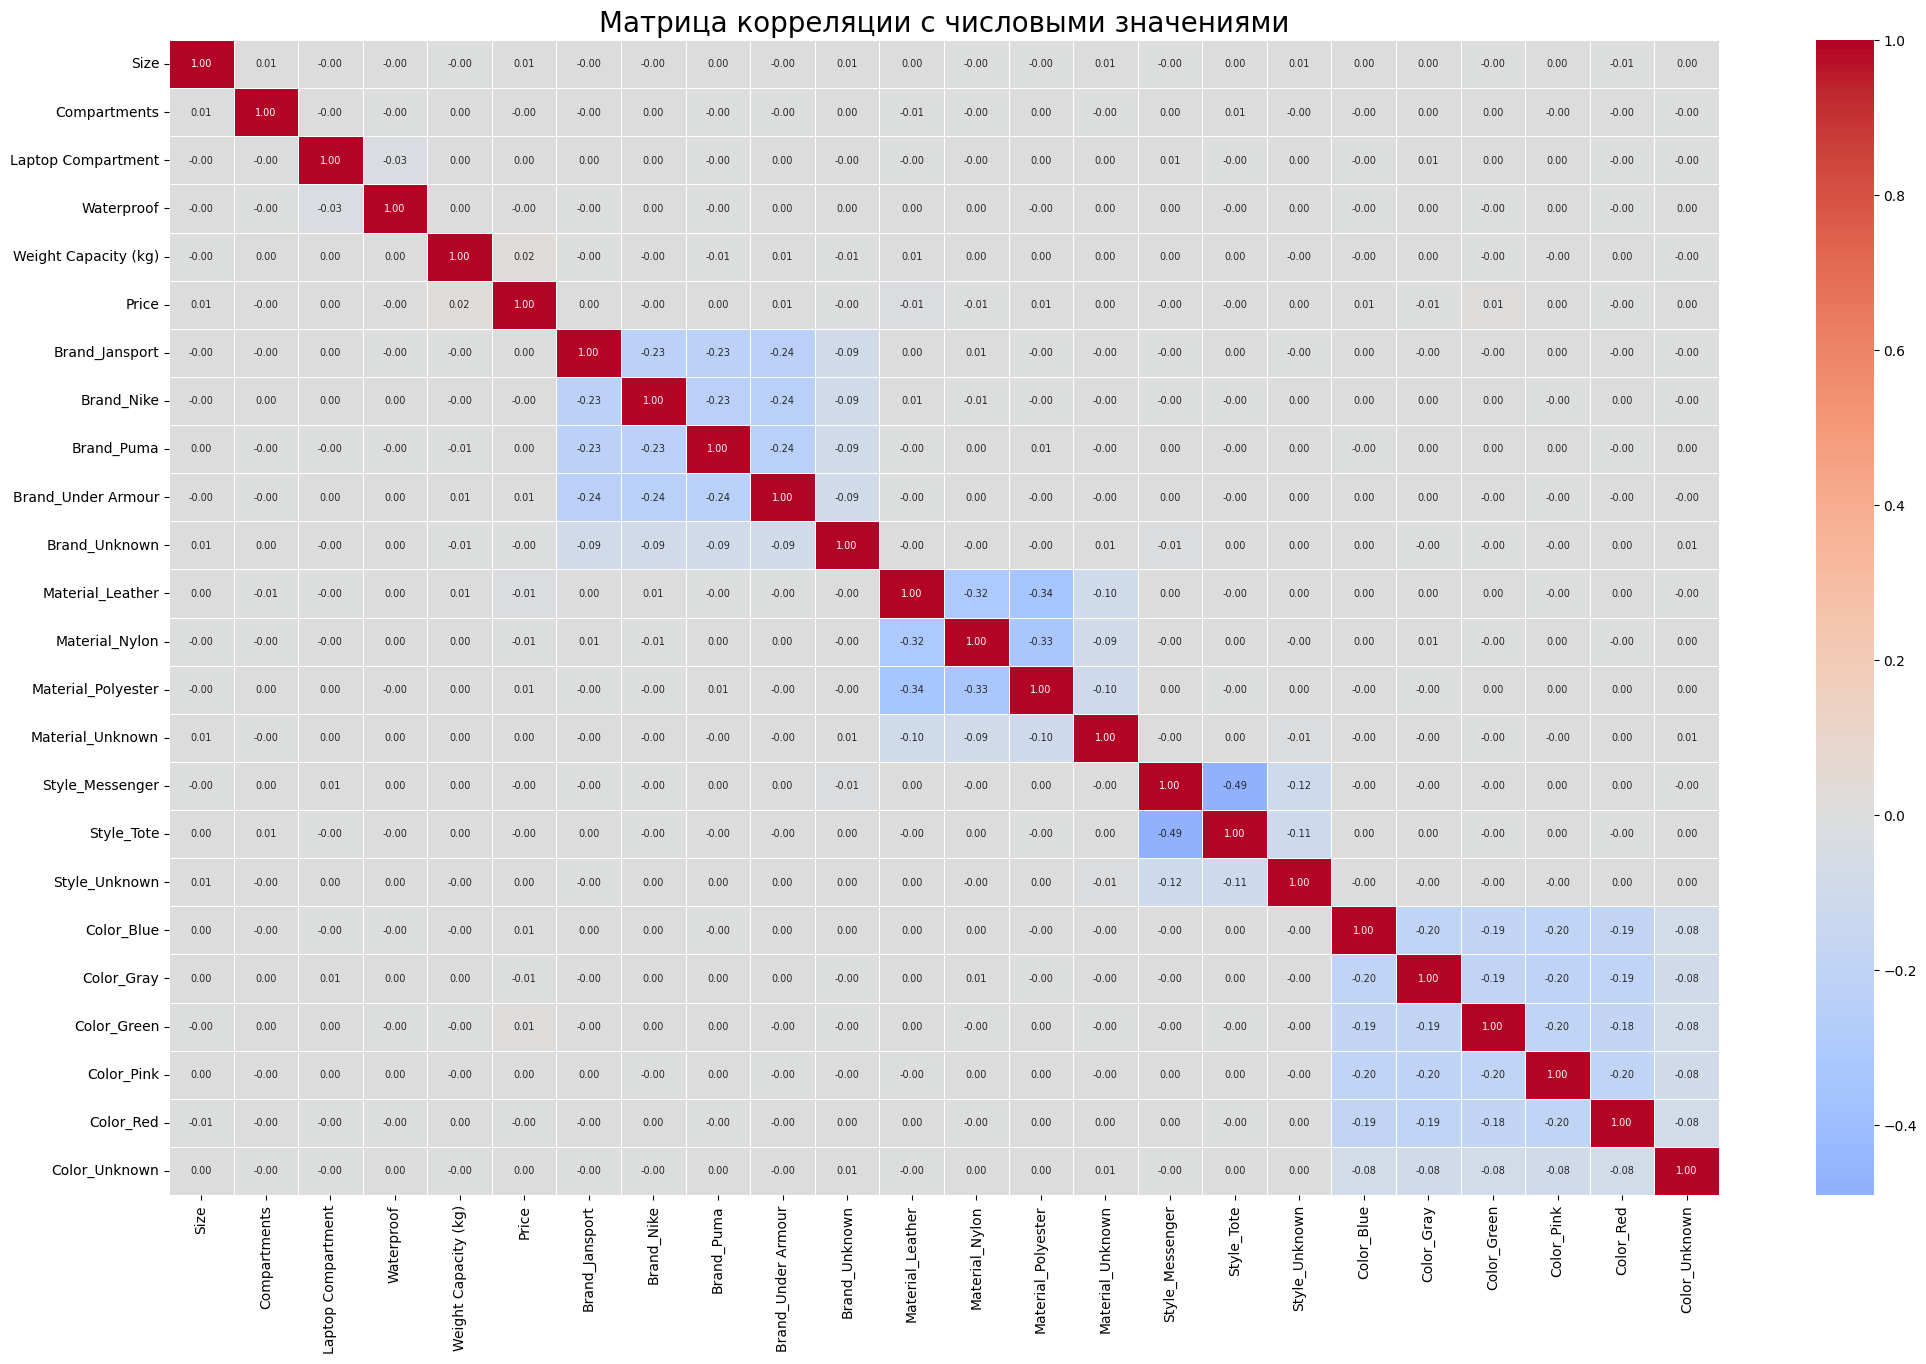

Средняя абсолютная корреляция между всеми признаками: 0.0245


In [44]:
corr_matrix = df_encoded.corr()

plt.figure(figsize=(25, 15))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title('Матрица корреляции с числовыми значениями', fontsize=20)
plt.show()

mask = np.ones(corr_matrix.shape, dtype=bool)
np.fill_diagonal(mask, 0)
avg_corr = corr_matrix.where(mask).abs().mean().mean()

print(f"Средняя абсолютная корреляция между всеми признаками: {avg_corr:.4f}")